In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path.cwd().parent / "data"
CLASSES = ["truck · ambient", "truck · reefer", "van · ambient", "van · reefer"]
COLOR = dict(zip(CLASSES, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))
TOTAL, CHILLED = "#2a78d6", "#1baf7a"
DEPOTS = ["Peliyagoda", "Kandy"]
METRICS = {"weight": ("weight_cap_kg", "order_weight_kg", "kg", "Weight"),
           "volume": ("volume_cap_m3", "order_volume_m3", "m³", "Volume")}
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "font.size": 10,
})

In [2]:
vehicles = pd.read_csv(DATA / "General Data/vehicles.csv").rename(columns=str.strip)
vehicles["cls"] = vehicles.type + " · " + vehicles.temp
orders = pd.concat([pd.read_csv(DATA / "Training Data/deliveries_train.csv"),
                    pd.read_csv(DATA / "Test Data/task1_test_inputs.csv")], ignore_index=True)
orders["order_date"] = pd.to_datetime(orders.order_date)
print(f"{len(vehicles)} vehicles, {len(orders):,} orders")

60 vehicles, 97,321 orders


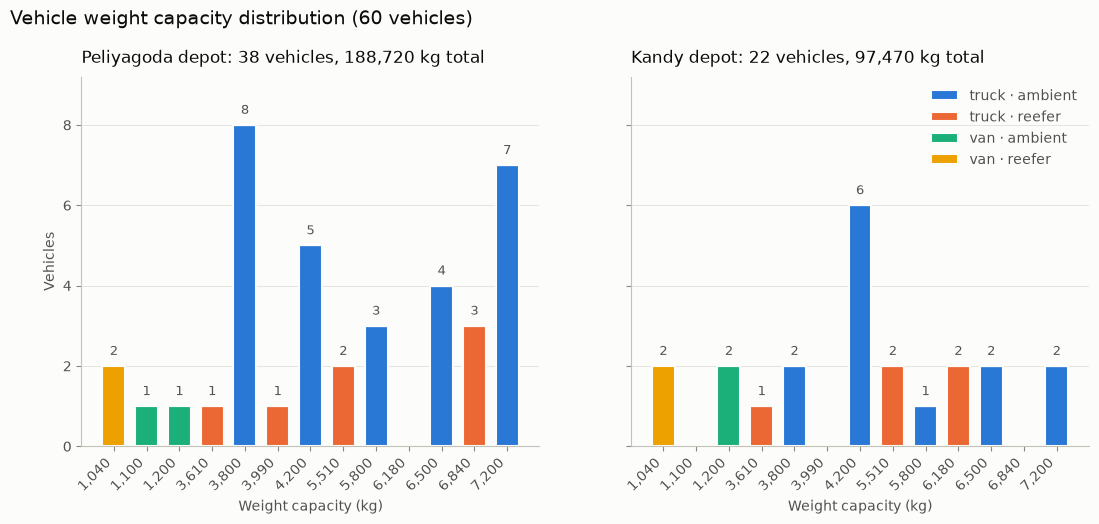

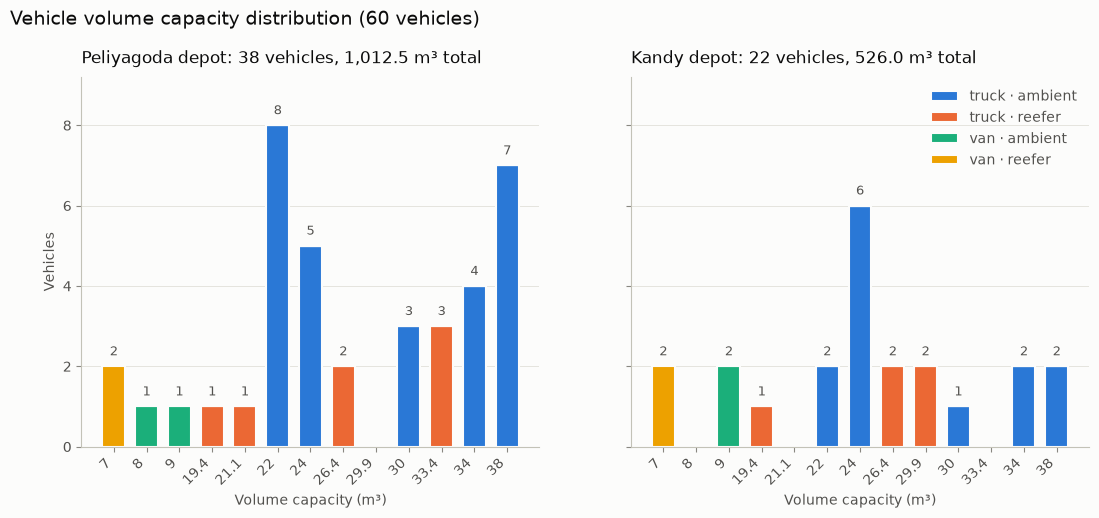

In [3]:
for metric, (col, _, unit, label) in METRICS.items():
    values = sorted(vehicles[col].unique())
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
    for ax, depot in zip(axes, DEPOTS):
        sub = vehicles[vehicles.depot == depot]
        counts = sub.groupby([col, "cls"]).size().unstack(fill_value=0).reindex(values, fill_value=0)
        x = np.arange(len(values))
        bottom = np.zeros(len(values))
        for cls in CLASSES:
            n = counts.get(cls, pd.Series(0, index=values)).values
            ax.bar(x, n, bottom=bottom, color=COLOR[cls], width=0.7, edgecolor=SURFACE, linewidth=1.5, label=cls)
            bottom += n
        for xi, total in zip(x, bottom):
            if total:
                ax.text(xi, total + 0.2, f"{int(total)}", ha="center", va="bottom", fontsize=9, color=INK_2)
        ax.set_xticks(x, [f"{v:,.0f}" if metric == "weight" else f"{v:g}" for v in values], rotation=45, ha="right")
        ax.set_xlabel(f"{label} capacity ({unit})")
        ax.grid(axis="x", visible=False)
        ax.set_ylim(0, vehicles.groupby(["depot", col]).size().max() * 1.15)
        ax.set_title(f"{depot} depot: {len(sub)} vehicles, {sub[col].sum():,.{0 if metric == 'weight' else 1}f} {unit} total")
    axes[0].set_ylabel("Vehicles")
    axes[1].legend(frameon=False, loc="upper right", labelcolor=INK_2)
    fig.suptitle(f"Vehicle {label.lower()} capacity distribution (60 vehicles)", x=0.07, ha="left",
                 fontsize=14, color=INK, y=1.02)
    plt.show()

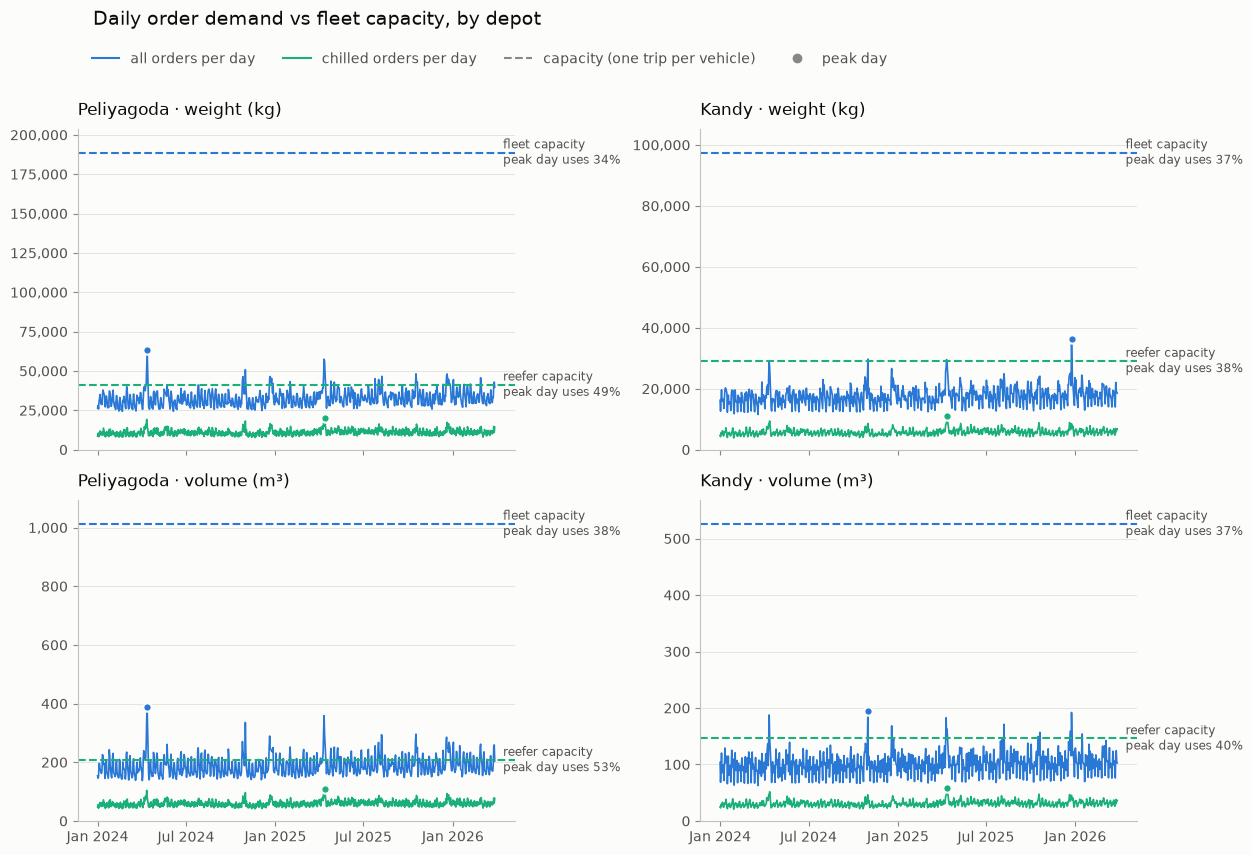

In [4]:
rows = []
for depot in DEPOTS:
    fleet = vehicles[vehicles.depot == depot]
    reefer = fleet[fleet.temp == "reefer"]
    o = orders[orders.depot == depot]
    for metric, (vcol, ocol, _, _) in METRICS.items():
        total = o.groupby("order_date")[ocol].sum()
        chilled = o[o.temp_requirement == "chilled"].groupby("order_date")[ocol].sum().reindex(total.index, fill_value=0)
        rows.append(dict(depot=depot, metric=metric, total=total, chilled=chilled,
                         fleet_cap=fleet[vcol].sum(), reefer_cap=reefer[vcol].sum()))

fig, axes = plt.subplots(2, 2, figsize=(14, 8.5), sharex=True)
for ax, r in zip(axes.T.flat, rows):
    _, _, unit, label = METRICS[r["metric"]]
    ax.plot(r["total"].index, r["total"].values, color=TOTAL, lw=1.2)
    ax.plot(r["chilled"].index, r["chilled"].values, color=CHILLED, lw=1.2)
    ax.axhline(r["fleet_cap"], color=TOTAL, lw=1.5, ls="--")
    ax.axhline(r["reefer_cap"], color=CHILLED, lw=1.5, ls="--")
    right = r["total"].index.max()
    for series, cap, name, c in [(r["total"], r["fleet_cap"], "fleet capacity", TOTAL),
                                 (r["chilled"], r["reefer_cap"], "reefer capacity", CHILLED)]:
        ax.annotate(f"{name}\npeak day uses {series.max() / cap:.0%}", (right, cap), xytext=(6, 0),
                    textcoords="offset points", va="center", fontsize=8.5, color=INK_2, linespacing=1.3)
        ax.plot([series.idxmax()], [series.max()], marker="o", ms=6, color=c, mec=SURFACE, mew=1.5, zorder=5)
    ax.set_ylim(0, r["fleet_cap"] * 1.08)
    ax.set_title(f"{r['depot']} · {label.lower()} ({unit})")
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
    ax.grid(axis="x", visible=False)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
handles = [plt.Line2D([], [], color=TOTAL, lw=1.5), plt.Line2D([], [], color=CHILLED, lw=1.5),
           plt.Line2D([], [], color=MUTED, lw=1.5, ls="--"), plt.Line2D([], [], color=MUTED, marker="o", ls="", ms=6)]
fig.legend(handles, ["all orders per day", "chilled orders per day", "capacity (one trip per vehicle)", "peak day"],
           frameon=False, loc="upper left", bbox_to_anchor=(0.06, 0.965), ncol=4, labelcolor=INK_2)
fig.suptitle("Daily order demand vs fleet capacity, by depot", x=0.07, ha="left", fontsize=14, color=INK, y=1.0)
fig.tight_layout(rect=(0, 0, 0.9, 0.95))
plt.show()

In [5]:
total = orders.groupby("order_date")[["order_weight_kg", "order_volume_m3"]].sum()
w = total.order_weight_kg > vehicles.weight_cap_kg.sum()
v = total.order_volume_m3 > vehicles.volume_cap_m3.sum()
print(f"Days with orders: {orders.order_date.nunique()}")
print(f"Whole fleet: weight {w.sum()}, volume {v.sum()}, either {(w | v).sum()} days")
for depot in DEPOTS:
    by = {r["metric"]: r for r in rows if r["depot"] == depot}
    w, v = by["weight"], by["volume"]
    over = (w["total"] > w["fleet_cap"]) | (v["total"] > v["fleet_cap"])
    chill = (w["chilled"] > w["reefer_cap"]) | (v["chilled"] > v["reefer_cap"])
    print(f"{depot} all orders: {over.sum()} days (peak {w['total'].max() / w['fleet_cap']:.0%} weight, "
          f"{v['total'].max() / v['fleet_cap']:.0%} volume)")
    print(f"{depot} chilled vs reefers: {chill.sum()} days (peak {w['chilled'].max() / w['reefer_cap']:.0%} "
          f"weight, {v['chilled'].max() / v['reefer_cap']:.0%} volume)")
ran = orders[orders.dispatch_status == "attempted"]
ran_ids = ran.groupby(pd.to_datetime(ran.dispatch_date)).vehicle_id.unique()
caps = vehicles.set_index("vehicle_id")[["weight_cap_kg", "volume_cap_m3"]]
used = pd.DataFrame([caps.loc[ids].sum() for ids in ran_ids], index=ran_ids.index)
j = total.join(used, how="inner")
over = (j.order_weight_kg > j.weight_cap_kg) | (j.order_volume_m3 > j.volume_cap_m3)
print(f"Vehicles used that day: {over.sum()} days (peak {(j.order_weight_kg / j.weight_cap_kg).max():.0%} weight, "
      f"{(j.order_volume_m3 / j.volume_cap_m3).max():.0%} volume)")

Days with orders: 695
Whole fleet: weight 0, volume 0, either 0 days
Peliyagoda all orders: 0 days (peak 34% weight, 38% volume)
Peliyagoda chilled vs reefers: 0 days (peak 49% weight, 53% volume)
Kandy all orders: 0 days (peak 37% weight, 37% volume)
Kandy chilled vs reefers: 0 days (peak 38% weight, 40% volume)
Vehicles used that day: 0 days (peak 75% weight, 79% volume)
